In [39]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper_function import plot_decision_boundary, accuracy_fn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [40]:
X, y = make_circles(n_samples = 1000, noise = 0.03, random_state = 42)
X[:5]

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       [-0.39373073,  0.69288277],
       [ 0.44220765, -0.89672343]])

In [41]:
df = pd.DataFrame(X[:, 0], X[:, 1])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0.23148073787097836 to 0.9638244328164373
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1000 non-null   float64
dtypes: float64(1)
memory usage: 15.6 KB


In [42]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
len(X_train)

800

In [44]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [45]:
X.dim(), y.dim()

(2, 1)

In [46]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(
            in_features = 2, out_features = 64
        )
        #self.layer_2 = nn.Linear(
        #    in_features = 64, out_features = 64
        #)
        self.layer_2 = nn.ReLU()
        self.layer_3 = nn.Linear(
            in_features = 64, out_features = 1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_3(self.layer_2(self.layer_1(x)))

In [47]:
model = CircleModel().to(device)
model

CircleModel(
  (layer_1): Linear(in_features=2, out_features=64, bias=True)
  (layer_2): ReLU()
  (layer_3): Linear(in_features=64, out_features=1, bias=True)
)

In [48]:
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

In [49]:
def train_model(model, epochs, loss_fn, optimizer):
    for epoch in range(epochs):
        model.train()
        y_logits = model(X_train).squeeze()
        y_pred = torch.round(torch.sigmoid(y_logits))
    
        train_accuracy = accuracy_fn(y_train, y_pred)
    
        loss = loss_fn(y_logits, y_train)
        optimizer.zero_grad()
    
        loss.backward()
        optimizer.step()
    
        model.eval()
        with torch.inference_mode():
            y_test_logits = model(X_test).squeeze()
            y_test_pred = torch.round(torch.sigmoid(y_test_logits))
            test_accuracy = accuracy_fn(y_test, y_test_pred)
    
            test_loss = loss_fn(y_test_logits, y_test)
    
        if epoch % (0.2 * epochs) == 0:
            print(f"Training Loss: {loss} | Testing Loss {test_loss}")
            print(f"Training Accuracy: {train_accuracy} | Testing Accuracy: {test_accuracy}")

In [50]:
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.01)

In [51]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [52]:
train_model(model, 1000, loss_fn, optimizer)

Training Loss: 0.6954852342605591 | Testing Loss 0.7018705606460571
Training Accuracy: 50.875 | Testing Accuracy: 47.5
Training Loss: 0.02912251465022564 | Testing Loss 0.051615871489048004
Training Accuracy: 100.0 | Testing Accuracy: 100.0
Training Loss: 0.008441912941634655 | Testing Loss 0.021504592150449753
Training Accuracy: 100.0 | Testing Accuracy: 100.0
Training Loss: 0.004277043975889683 | Testing Loss 0.01378726027905941
Training Accuracy: 100.0 | Testing Accuracy: 100.0
Training Loss: 0.0026198839768767357 | Testing Loss 0.010157299228012562
Training Accuracy: 100.0 | Testing Accuracy: 100.0


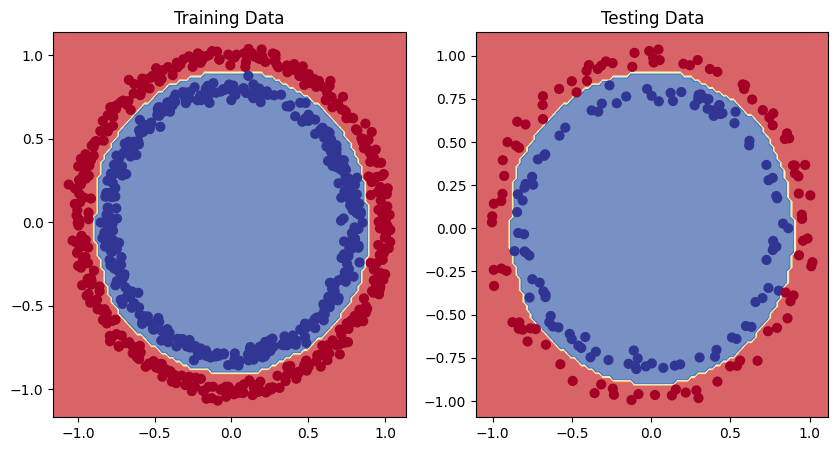

In [54]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Training Data")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Testing Data")
plot_decision_boundary(model, X_test, y_test)